In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df=pd.read_csv('insurance.csv')

In [35]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [36]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


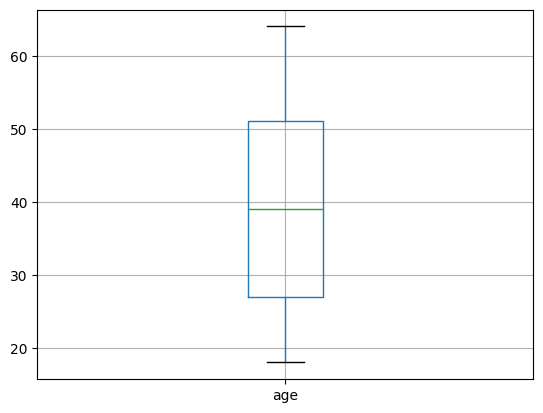

In [38]:
df.boxplot(column=['age'])
plt.show()

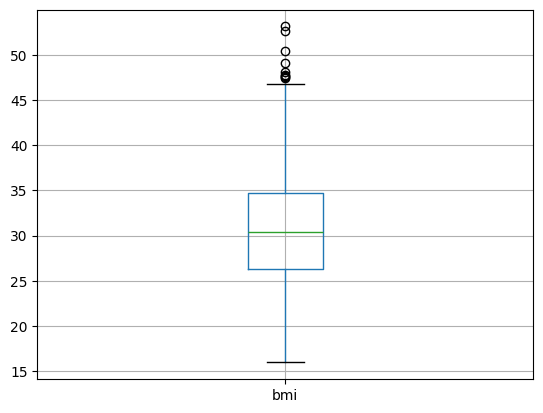

In [39]:
df.boxplot(column=['bmi'])
plt.show()

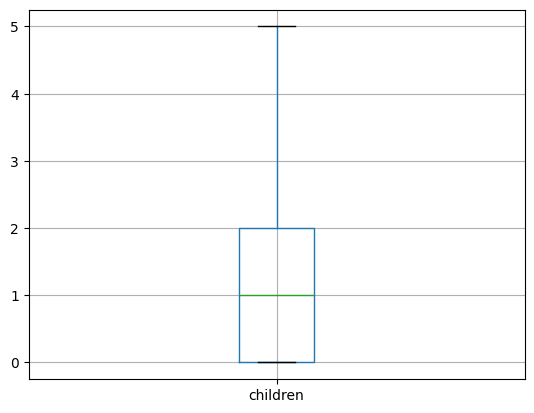

In [40]:
df.boxplot(column=['children'])
plt.show()

In [41]:
Q1=df['bmi'].quantile(0.25)
Q3=df['bmi'].quantile(0.75)
IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

In [42]:
#capping
df['bmi']=df['bmi'].clip(lower=lower_bound,upper=upper_bound)

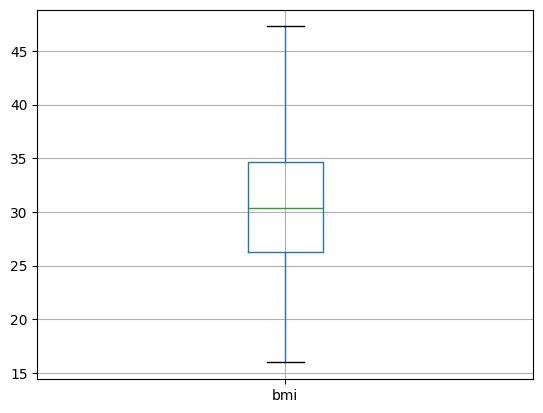

In [43]:
# after capping
df.boxplot(column=['bmi'])
plt.show()

In [44]:
def show_corr(dataset, target_name, n_most=None):
    if n_most is None:
        n_most=len(dataset.columns.values)-1
    corr_matrix=dataset.corr(numeric_only=True).abs()

    most_correlated_features=corr_matrix[target_name].sort_values(ascending=False).drop(target_name)

    most_correlated_feature_names=most_correlated_features.index.values

    fig, ax=plt.subplots(figsize=(15,5))
    sns.barplot(x=most_correlated_feature_names, y=most_correlated_features)
    plt.title(" Correlation of features with {}".format(target_name))

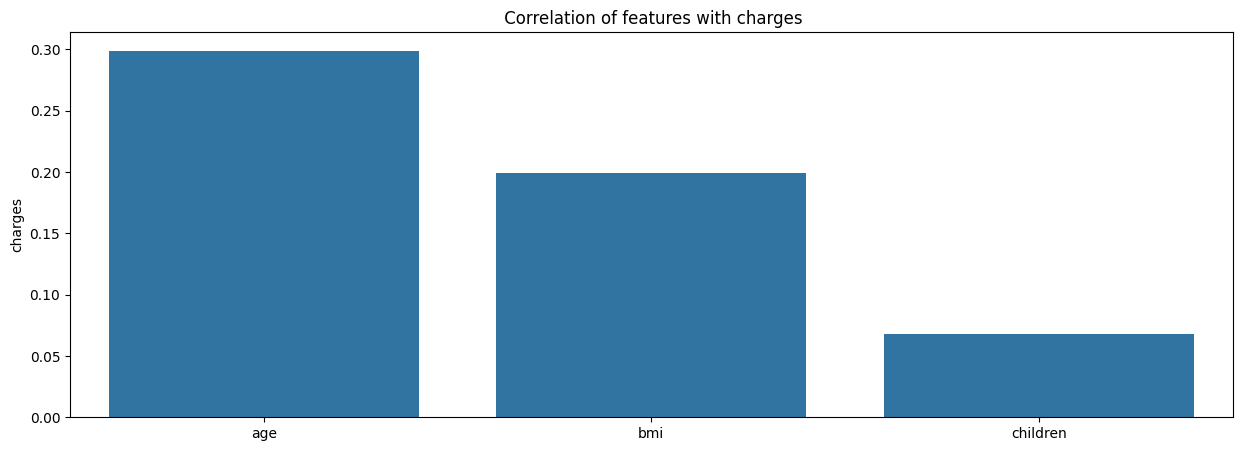

In [45]:
show_corr(dataset=df, target_name='charges')

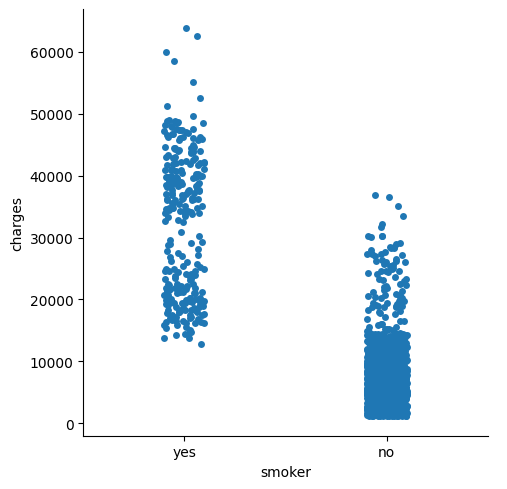

In [46]:
corr_smoker_charges=sns.catplot(data=df,x='smoker',y='charges')

In [47]:
# Encoding
df_encoded=pd.get_dummies(data=df,columns=['sex','smoker','region'])

In [48]:
df_encoded.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [49]:
X=df_encoded.drop(columns=['charges'])

In [50]:
X

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,False,True
1,18,33.770,1,False,True,True,False,False,False,True,False
2,28,33.000,3,False,True,True,False,False,False,True,False
3,33,22.705,0,False,True,True,False,False,True,False,False
4,32,28.880,0,False,True,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,False,True,True,False,False,True,False,False
1334,18,31.920,0,True,False,True,False,True,False,False,False
1335,18,36.850,0,True,False,True,False,False,False,True,False
1336,21,25.800,0,True,False,True,False,False,False,False,True


In [51]:
Y=df_encoded.loc[:,'charges']

In [52]:
Y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


**Model Training**

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,train_size=0.8,random_state=42)

**Standardization**

In [55]:
from sklearn.preprocessing import MinMaxScaler

In [56]:
scaler_func=MinMaxScaler()
X_train=scaler_func.fit_transform(X_train)
X_test=scaler_func.transform(X_test)

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor

from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [58]:
linear_regression_model=LinearRegression()
decision_tree_model=DecisionTreeRegressor()
random_forest_model=RandomForestRegressor()
gradient_boosting_model=GradientBoostingRegressor()
adaboost_model=AdaBoostRegressor()

In [59]:
regression_models=[
    ('LinearRegression',linear_regression_model),
    ('DecisionTreeRegressor',decision_tree_model),
    ('RandomForestRegressor',random_forest_model),
    ('GradientBoostingRegressor',gradient_boosting_model),
    ('AdaBoostRegressor',adaboost_model)
    ]

**K-Fold Validation**

In [60]:
from sklearn.model_selection import cross_val_score

In [61]:
r2_scores=[]
for regression_name,regression_model in regression_models:
  cross_validation_scores=cross_val_score(regression_model,X_train,Y_train,cv=5,scoring='r2')
  r2_scores.append(cross_validation_scores.mean()*100)

  print(f"r2 score of {regression_name} - {round(cross_validation_scores.mean()*100,4)}%")


r2 score of LinearRegression - 73.3567%
r2 score of DecisionTreeRegressor - 70.9277%
r2 score of RandomForestRegressor - 82.8983%
r2 score of GradientBoostingRegressor - 84.0658%
r2 score of AdaBoostRegressor - 80.8417%


**Evaluation on Test data**

In [62]:
best_model = GradientBoostingRegressor()

best_model.fit(X_train, Y_train)

y_pred = best_model.predict(X_test)

In [63]:
r2 = r2_score(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)

print("R²:", round(r2*100,4),"%\n")
print("MAE:", round(mae*100,4))
print("MSE:", round(mse*100,4))
print("RMSE:", round(rmse*100,4))

R²: 87.9404 %

MAE: 240486.9311
MSE: 1872240062.7548
RMSE: 432693.8944


**Test of R^2 of Training data Vs Test data**

In [64]:
model = GradientBoostingRegressor()
model.fit(X_train, Y_train)

print("Train R²:", model.score(X_train, Y_train))
print("Test R² :", model.score(X_test, Y_test))

Train R²: 0.8997306137069336
Test R² : 0.8795625892559488
